In [228]:
from analyses import parse
import plotly.express as px
import plotly.graph_objects as go
import polars as pl
import numpy as np
import colorir as cl
from pathlib import Path

In [229]:
interval = 10_000
dts = np.concat([
    [10], 
    np.arange(
        interval,
        1_000_000 + interval,
        interval,
        dtype=int
    )
])
dts

array([     10,   10000,   20000,   30000,   40000,   50000,   60000,
         70000,   80000,   90000,  100000,  110000,  120000,  130000,
        140000,  150000,  160000,  170000,  180000,  190000,  200000,
        210000,  220000,  230000,  240000,  250000,  260000,  270000,
        280000,  290000,  300000,  310000,  320000,  330000,  340000,
        350000,  360000,  370000,  380000,  390000,  400000,  410000,
        420000,  430000,  440000,  450000,  460000,  470000,  480000,
        490000,  500000,  510000,  520000,  530000,  540000,  550000,
        560000,  570000,  580000,  590000,  600000,  610000,  620000,
        630000,  640000,  650000,  660000,  670000,  680000,  690000,
        700000,  710000,  720000,  730000,  740000,  750000,  760000,
        770000,  780000,  790000,  800000,  810000,  820000,  830000,
        840000,  850000,  860000,  870000,  880000,  890000,  900000,
        910000,  920000,  930000,  940000,  950000,  960000,  970000,
        980000,  990

In [230]:
sim_paths = {}
for path in Path("../runs/speed/").iterdir():
    sim_type = path.name
    gamma = 20 - int(sim_type.split("-")[1])
    for replica_path in path.iterdir():
        replica = int(replica_path.name)
        sim_paths[(gamma, replica)] = replica_path
sims = parse.parse_cells_multiple(sim_paths.values(), 30)
sim_ids = list(sim_paths.keys())
for i in range(len(sims)):
    sims[i] = sims[i].with_columns(
        gamma=sim_ids[i][0], 
        sim_replica=sim_ids[i][1]
    )
cellveldf = pl.concat(sims)

In [247]:
stdf = cellveldf\
    .with_columns(displ=(pl.col("center_x") ** 2 + pl.col("center_y") ** 2) ** 0.5)\
    .with_columns(mean_displ=pl.col("displ").mean().over(["gamma", "sim_replica", "wtime"]))\
    .filter(pl.col("wtime") > 25e4)\
    .sort("wtime")\
    .group_by("gamma")\
    .agg(
        steady_time=pl.col("wtime").filter(pl.col("mean_displ") <= pl.col("mean_displ").filter(pl.col("wtime") > 1e7).mean()).min()
    )\
    .sort("gamma")
stdf

gamma,steady_time
i32,i32
0,600000
2,700000
4,600000
6,700000
8,1000000
…,…
12,1400000
14,1500000
16,1700000


In [234]:
# These sims should contain a single cell!!
sim_paths = {}
for sp in Path("../runs/msd/").iterdir():
    sim_type = sp.name
    gamma = 20 - int(sim_type.split("-")[1])
    for p in sp.iterdir():
        replica = int(p.name)
        sim_paths[(gamma, replica)] = p
    
sims = parse.parse_cells_multiple(
    sim_paths.values(),
    n_workers=24
)
celldf = pl.concat([sim.with_columns(gamma=k[0], replica=k[1]) for k, sim in zip(sim_paths, sims)])
assert (celldf["index"] == 0).all()
celldf

index,ancestor,area,target_area,perimeter,target_perimeter,center_x,center_y,chem_center_x,chem_center_y,chem_mass,ligands,receptors,time,wtime,gamma,replica
u32,u32,u32,u32,u32,u32,f32,f32,f32,f32,u32,u64,u64,u32,i32,i32,i32
0,0,200,200,182,180,120.510048,73.699982,120.47567,73.650696,113344,101,12,3100010,3200000,4,7
0,0,200,200,176,180,120.72506,73.314964,120.690414,73.266083,113347,101,12,3100020,3200000,4,7
0,0,200,200,180,180,120.505013,73.589966,120.470757,73.541222,113354,101,12,3100030,3200000,4,7
0,0,200,200,178,180,120.729988,73.779961,120.692894,73.729126,113299,101,12,3100040,3200000,4,7
0,0,200,200,176,180,120.639992,73.649956,120.602776,73.599197,113328,101,12,3100050,3200000,4,7
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,0,200,200,186,180,419.286469,425.67157,419.125153,425.629456,22092,13,106,1899960,1900000,16,8
0,0,200,200,182,180,419.521423,425.781586,419.365295,425.746124,22042,13,106,1899970,1900000,16,8
0,0,201,200,180,180,419.444183,425.762726,419.291473,425.725281,22167,13,106,1899980,1900000,16,8


In [248]:
displdf = celldf.select(
    "gamma",
    "replica",
    "time",
    displ=(pl.col("center_x") ** 2 + pl.col("center_y") ** 2) ** 0.5
).sort([
    "gamma", 
    "replica",
    "time"
]).join(
    stdf, 
    on="gamma"
).filter(pl.col("gamma").is_in([0, 12]))  # Which simes to show
displdf

gamma,replica,time,displ,steady_time
i32,i32,u32,f32,i32
0,0,0,652.73468,600000
0,0,10,649.896301,600000
0,0,20,647.664978,600000
0,0,30,646.699524,600000
0,0,40,646.428101,600000
…,…,…,…,…
12,20,4999960,336.874084,1400000
12,20,4999970,337.026672,1400000
12,20,4999980,337.030884,1400000


In [269]:
msddf = pl.DataFrame()
for dt in dts:
    filterdf = displdf.filter(
        pl.col("time") % dt == 0,
        pl.col("time") > 25e4,
        pl.col("time") < 1400000
    ).filter(pl.col("time").n_unique().over(["gamma", "replica"]) > 2)
    msd = filterdf\
        .group_by(["gamma", "replica"])\
        .agg(
            msd=(pl.col("displ").diff() ** 2).mean()
        )\
        .with_columns(dt=dt)
    msddf = pl.concat([msddf, msd])
msddf

gamma,replica,msd,dt
i32,i32,f32,i64
0,17,0.063261,10
12,4,0.034821,10
12,17,0.034658,10
0,1,0.085836,10
0,15,0.053323,10
…,…,…,…
12,7,1724.347168,460000
0,6,3329.581055,460000
12,13,388.810669,460000


In [270]:
aggdf = msddf.group_by(["gamma", "dt"]).agg(
    mean=pl.col("msd").mean(),
    med=pl.col("msd").median(),
    min=pl.col("msd").min(),
    max=pl.col("msd").max(),
    std1=pl.col("msd").mean() + 1.5 * pl.col("msd").std(),
    std2=pl.col("msd").mean() - 1.5 * pl.col("msd").std()
).sort("dt").with_columns(
    pl.exclude(["gamma", "replica"]).log().name.prefix("ln_")
)
aggdf

gamma,dt,mean,med,min,max,std1,std2,ln_dt,ln_mean,ln_med,ln_min,ln_max,ln_std1,ln_std2
i32,i64,f32,f32,f32,f32,f32,f32,f64,f32,f32,f32,f32,f32,f32
12,10,0.035914,0.035301,0.033758,0.040842,0.038513,0.033315,2.302585,-3.32663,-3.343853,-3.388546,-3.198045,-3.256765,-3.401745
0,10,0.058399,0.057299,0.031024,0.120145,0.088607,0.028192,2.302585,-2.840454,-2.859472,-3.473006,-2.11906,-2.42355,-3.568725
0,10000,69.97596,55.093403,10.181989,333.747986,176.858978,-36.907051,9.21034,4.248152,4.00903,2.320621,5.810387,5.175353,NaN
12,10000,10.610012,10.218346,7.765408,17.132339,13.815664,7.40436,9.21034,2.361798,2.324185,2.049679,2.840968,2.625803,2.002069
12,20000,18.330217,16.606728,8.919763,31.303749,25.447231,11.213203,9.903488,2.908551,2.809808,2.18827,3.443738,3.236607,2.417092
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,440000,6247.558105,5328.291016,183.84996,17097.771484,13213.667969,-718.551758,12.99453,8.739947,8.580787,5.21412,9.746704,9.489008,NaN
0,450000,6174.438477,5434.582031,307.489441,17061.201172,13180.146484,-831.269531,13.017003,8.728174,8.600539,5.728441,9.744563,9.486468,NaN
12,450000,630.018127,674.860474,64.816277,1576.650269,1283.224609,-23.188293,13.017003,6.445749,6.514506,4.171557,7.363058,7.157132,NaN


In [271]:
palette = cl.StackPalette().load("carnival")
grad = cl.PolarGrad(palette, domain=[0, 20])
palette

/tmp/ipykernel_1752701/3214442565.py:1: FutureWarning:

'config.DEFAULT_PALETTES_DIR' is going to change to the current directory on the next minor release, specify 'palettes_dir=colorir.config.USR_PALETTES_DIR' to disable this warning



     #e7f8bf
     #98d5a4
     #3faf99
     #008692
     #005986
     #3b2179
     #823083
     #b75687
     #dd867f
     #f4bc77
     #f8f68b

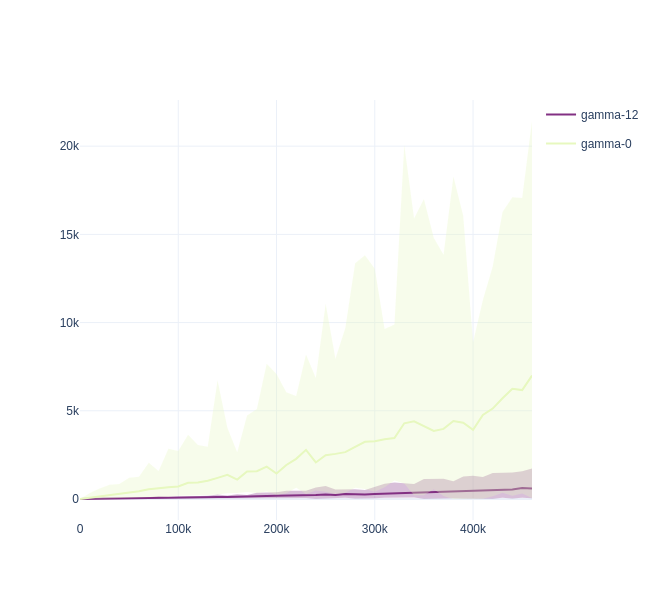

In [272]:
fig = go.Figure()
for gamma, group in aggdf.group_by("gamma"):
    gamma = gamma[0]
    color = grad(gamma)
    fig.add_traces([
        go.Scatter(
            x=group["dt"],
            y=group["mean"],
            mode="lines",
            line_color=color,
            name=f"gamma-{gamma}",
            legendgroup=gamma
        ),
        go.Scatter(
            x=pl.concat([group["dt"], group["dt"][::-1]]),
            y=pl.concat([group["min"], group["max"][::-1]]),
            mode="lines",
            line_color="rgba(0, 0, 0, 0)",
            fillcolor=color,
            opacity=0.3,
            fill="toself",
            hoverinfo="skip",
            showlegend=False,
            legendgroup=gamma
        )
    ])
fig.update_layout(
    template="plotly_white",
    width=400,
    height=600
)

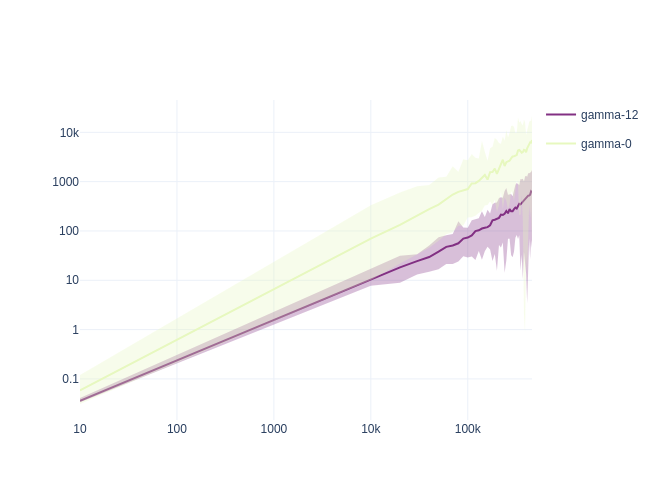

In [273]:
fig.update_layout(
    xaxis_type="log",
    yaxis_type="log",
    width=500,
    height=500
)